In [ ]:
# Cell 1 — just install and restart, no assert here
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy==1.26.4",
    "transformers==4.46.3",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "sentencepiece", "scikit-learn",
    "pandas", "pyarrow", "evaluate",
])

print("✅ Installed — restarting now...")
import os
os.kill(os.getpid(), 9)

In [2]:
import os
from google.colab import drive

drive.mount("/content/drive")

for d in [DRIVE_DIR, CHECKPOINT_DIR, DATA_DIR, f"{DATA_DIR}/raw"]:
    os.makedirs(d, exist_ok=True)

r = __import__("subprocess").run(["df","-h","/content"], capture_output=True, text=True)
print(r.stdout)
print(f"✅ Drive mounted → {DRIVE_DIR}")

Mounted at /content/drive
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   69G  39% /

✅ Drive mounted → /content/drive/MyDrive/PRAMAN_detector


---
## Stream RAID Dataset
> RAID uses `model` field: `'human'` = label 0, any AI model name = label 1

In [3]:
import pandas as pd
import gc
from datasets import load_dataset

TARGET = 75_000   # 75K human + 75K AI
print(f"📥 Streaming RAID (target: {TARGET:,} per class)...")

stream = load_dataset("liamdugan/raid", split="train", streaming=True)
rows, n_human, n_ai = [], 0, 0

for i, ex in enumerate(stream):
    text  = (ex.get("generation") or "").strip()
    model = (ex.get("model") or "").lower()
    if not text or len(text.split()) < 30:
        continue
    if model == "human" and n_human < TARGET:
        rows.append({"text": text, "label": 0})
        n_human += 1
    elif model not in ("human", "") and n_ai < TARGET:
        rows.append({"text": text, "label": 1})
        n_ai += 1
    if n_human >= TARGET and n_ai >= TARGET:
        break
    if i % 20_000 == 0 and i > 0:
        print(f"  row {i:,} → human:{n_human:,} ai:{n_ai:,}")

df = pd.DataFrame(rows)
df.to_parquet(f"{DATA_DIR}/raw/raid.parquet", index=False)
print(f"✅ RAID: {len(df):,} rows")
print(df["label"].value_counts())

del stream, rows
gc.collect()

📥 Streaming RAID (target: 75,000 per class)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  row 20,000 → human:1,766 ai:18,096
  row 40,000 → human:3,241 ai:36,464
  row 60,000 → human:5,007 ai:54,569
  row 80,000 → human:6,281 ai:73,135
  row 100,000 → human:8,047 ai:75,000
  row 120,000 → human:9,323 ai:75,000
  row 140,000 → human:11,088 ai:75,000
  row 160,000 → human:12,361 ai:75,000
  row 180,000 → human:13,956 ai:75,000
  row 200,000 → human:15,602 ai:75,000
  row 220,000 → human:17,368 ai:75,000
  row 240,000 → human:18,642 ai:75,000
  row 260,000 → human:19,425 ai:75,000
  row 280,000 → human:19,425 ai:75,000
  row 300,000 → human:19,425 ai:75,000
  row 320,000 → human:19,425 ai:75,000
  row 340,000 → human:19,425 ai:75,000
  row 360,000 → human:19,425 ai:75,000
  row 380,000 → human:19,425 ai:75,000
  row 400,000 → human:19,425 ai:75,000
  row 420,000 → human:19,425 ai:75,000
  row 440,000 → human:19,425 ai:75,000
  row 460,000 → human:19,425 ai:75,000
  row 480,000 → human:19,425 ai:75,000
  row 500,000 → human:19,425 ai:75,000
  row 520,000 → human:19,425 ai:75,

62

---
## Stream MAGE Dataset
> MAGE uses `label` field: `0` = machine, `1` = human (we flip to our convention)

In [4]:
import pandas as pd
import gc
from datasets import load_dataset

TARGET = 75_000
print(f"📥 Streaming MAGE (target: {TARGET:,} per class)...")

stream = load_dataset("yaful/MAGE", split="train", streaming=True)
rows, n_human, n_ai = [], 0, 0

for i, ex in enumerate(stream):
    text      = (ex.get("text") or "").strip()
    label_raw = ex.get("label", -1)
    if not text or len(text.split()) < 30:
        continue
    # MAGE: 0=machine→our 1(AI), 1=human→our 0(human)
    label = 1 - int(label_raw)
    if label == 0 and n_human < TARGET:
        rows.append({"text": text, "label": 0})
        n_human += 1
    elif label == 1 and n_ai < TARGET:
        rows.append({"text": text, "label": 1})
        n_ai += 1
    if n_human >= TARGET and n_ai >= TARGET:
        break
    if i % 20_000 == 0 and i > 0:
        print(f"  row {i:,} → human:{n_human:,} ai:{n_ai:,}")

df = pd.DataFrame(rows)
df.to_parquet(f"{DATA_DIR}/raw/mage.parquet", index=False)
print(f"✅ MAGE: {len(df):,} rows")
print(df["label"].value_counts())

del stream, rows
gc.collect()

📥 Streaming MAGE (target: 75,000 per class)...


  row 20,000 → human:6,515 ai:12,836
  row 40,000 → human:6,515 ai:32,475
  row 60,000 → human:6,515 ai:51,821
  row 80,000 → human:6,515 ai:71,790
  row 100,000 → human:6,515 ai:75,000
  row 120,000 → human:6,515 ai:75,000
  row 140,000 → human:6,515 ai:75,000
  row 160,000 → human:6,515 ai:75,000
  row 180,000 → human:6,515 ai:75,000
  row 200,000 → human:6,515 ai:75,000
  row 220,000 → human:6,515 ai:75,000
  row 240,000 → human:13,364 ai:75,000
  row 260,000 → human:32,586 ai:75,000
  row 280,000 → human:49,928 ai:75,000
  row 300,000 → human:67,738 ai:75,000
✅ MAGE: 150,000 rows
label
0    75000
1    75000
Name: count, dtype: int64


8

---
##  Clean, Merge, Split

In [5]:
import re, unicodedata, gc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

raid = pd.read_parquet(f"{DATA_DIR}/raw/raid.parquet")
mage = pd.read_parquet(f"{DATA_DIR}/raw/mage.parquet")
df   = pd.concat([raid, mage], ignore_index=True)
print(f"Combined: {len(df):,}")

def clean(text):
    if not isinstance(text, str): return None
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"\S+@\S+\.\S+", "[EMAIL]", text)
    text = re.sub(r"\s+", " ", text).strip()
    w = text.split()
    return text if 30 <= len(w) <= 800 else None

df["text"] = df["text"].apply(clean)
df = df.dropna(subset=["text"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"After clean+dedup: {len(df):,}")

# Balance
n   = min(df["label"].value_counts().min(), 100_000)
df  = pd.concat([
    df[df["label"]==0].sample(n, random_state=42),
    df[df["label"]==1].sample(n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced: {len(df):,} ({n:,} per class)")

# Ensure label is plain Python int (critical!)
df["label"] = df["label"].astype(int)

# Split 80/10/10
tr, tmp = train_test_split(df, test_size=0.20, random_state=42, stratify=df["label"])
va, te  = train_test_split(tmp, test_size=0.50, random_state=42, stratify=tmp["label"])

tr.to_parquet(f"{DATA_DIR}/train.parquet", index=False)
va.to_parquet(f"{DATA_DIR}/val.parquet",   index=False)
te.to_parquet(f"{DATA_DIR}/test.parquet",  index=False)

print(f"\n✅ Split: train={len(tr):,} val={len(va):,} test={len(te):,}")
del df, raid, mage, tr, tmp, va, te
gc.collect()

Combined: 300,000
After clean+dedup: 251,924
Balanced: 200,000 (100,000 per class)

✅ Split: train=160,000 val=20,000 test=20,000


0

---
## Train
> Uses a **custom PyTorch Dataset** — labels are always `torch.long`, no Arrow dtype issues.
> Expected: ~90 minutes on T4.

In [11]:
import os, random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
)
import evaluate

# ── Auto-save and stop at step 400 ───────────────────────────────────
class SaveAndStopCallback(TrainerCallback):
    def __init__(self, stop_step, save_path, tokenizer):
        self.stop_step  = stop_step
        self.save_path  = save_path
        self.tokenizer  = tokenizer
        self.saved      = False

    def on_evaluate(self, args, state, control, **kwargs):
        if state.global_step >= self.stop_step and not self.saved:
            print(f"\n🛑 Step {state.global_step} reached — saving model now...")
            kwargs["model"].save_pretrained(self.save_path)
            self.tokenizer.save_pretrained(self.save_path)
            self.saved = True
            print(f"✅ Saved → {self.save_path}")
            control.should_training_stop = True   # stop training

# ── Custom Dataset — labels always torch.long ─────────────────────────
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tok    = tokenizer
        self.max    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Load tokenizer ────────────────────────────────────────────────────
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Load data ─────────────────────────────────────────────────────────
train_df = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val_df   = pd.read_parquet(f"{DATA_DIR}/val.parquet")
test_df  = pd.read_parquet(f"{DATA_DIR}/test.parquet")

train_df = train_df.sample(n=min(60_000, len(train_df)), random_state=42).reset_index(drop=True)

print(f"Label dtype: {train_df['label'].dtype} ✅")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

train_ds = TextDataset(train_df, tokenizer, MAX_LEN)
val_ds   = TextDataset(val_df,   tokenizer, MAX_LEN)
test_ds  = TextDataset(test_df,  tokenizer, MAX_LEN)

sample = train_ds[0]
assert sample["labels"].dtype == torch.long
assert sample["labels"].item() in (0, 1)
print(f"Sanity check: label={sample['labels'].item()} dtype={sample['labels'].dtype} ✅")

# ── Load model ────────────────────────────────────────────────────────
print(f"\nLoading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "HUMAN", 1: "AI"},
    label2id={"HUMAN": 0, "AI": 1},
    ignore_mismatched_sizes=True,
)
model.gradient_checkpointing_enable()
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.0f}M ✅")

# ── Metrics ───────────────────────────────────────────────────────────
acc_m = evaluate.load("accuracy")
f1_m  = evaluate.load("f1")

def compute_metrics(ep):
    preds  = np.argmax(ep.predictions, axis=-1)
    labels = ep.label_ids
    return {
        "accuracy": acc_m.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       f1_m.compute( predictions=preds, references=labels, average="weighted")["f1"],
    }

# ── Training args ─────────────────────────────────────────────────────
args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    fp16=False,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    eval_strategy="steps",
    eval_steps=400,
    save_strategy="steps",
    save_steps=400,
    save_total_limit=2,
    load_best_model_at_end=False,   # False so we don't reload after stop
    logging_steps=100,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        SaveAndStopCallback(
            stop_step=400,
            save_path=MODEL_SAVE,
            tokenizer=tokenizer
        )
    ],
)

print(f"\n🚀 Training started — will auto-save and stop at step 400 (~45 min)\n")
trainer.train()

# Fallback save in case callback didn't trigger
if not os.path.exists(f"{MODEL_SAVE}/config.json"):
    print("Fallback save...")
    trainer.save_model(MODEL_SAVE)
    tokenizer.save_pretrained(MODEL_SAVE)

print(f"\n✅ Done!")
print(f"   Saved to: {MODEL_SAVE}")
print(f"   Files: {os.listdir(MODEL_SAVE)}")

Loading tokenizer: microsoft/deberta-v3-base


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Label dtype: int64 ✅
Train: 60,000 | Val: 20,000 | Test: 20,000
Sanity check: label=0 dtype=torch.int64 ✅

Loading model: microsoft/deberta-v3-base


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 184M ✅

🚀 Training started — will auto-save and stop at step 400 (~45 min)



Step,Training Loss,Validation Loss


Step,Training Loss,Validation Loss,Accuracy,F1
400,0.183300,0.190181,0.938250,0.938117



🛑 Step 400 reached — saving model now...
✅ Saved → /content/drive/MyDrive/PRAMAN_detector/final_model

✅ Done!
   Saved to: /content/drive/MyDrive/PRAMAN_detector/final_model
   Files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'spm.model', 'tokenizer.json', 'training_args.bin']


---
## Evaluate

Evaluating on test set...



              precision    recall  f1-score   support

       Human       0.98      0.89      0.93     10000
          AI       0.90      0.99      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000

ROC-AUC: 0.9880


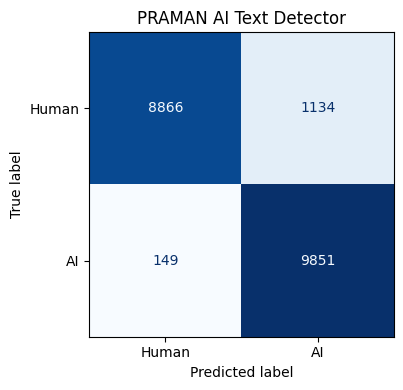

✅ Saved to /content/drive/MyDrive/PRAMAN_detector/confusion_matrix.png


In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

print("Evaluating on test set...")
out    = trainer.predict(test_ds)
preds  = np.argmax(out.predictions, axis=-1)
labels = out.label_ids
probs  = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()

print("\n" + "="*50)
print(classification_report(labels, preds, target_names=["Human","AI"]))
print(f"ROC-AUC: {roc_auc_score(labels, probs[:,1]):.4f}")

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(
    confusion_matrix(labels, preds),
    display_labels=["Human","AI"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("PRAMAN AI Text Detector")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print(f"✅ Saved to {DRIVE_DIR}/confusion_matrix.png")

---
##  Upload to HuggingFace Hub
> Get your token from huggingface.co/settings/tokens

In [ ]:
from huggingface_hub import HfApi, login

HF_TOKEN    = "#######################"          # ← paste your token
HF_USERNAME = "animan0810"            # ← paste your username
REPO_ID     = f"{HF_USERNAME}/pramaan-ai-detector"

login(token=HF_TOKEN)
api = HfApi()

api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)
api.upload_folder(folder_path=MODEL_SAVE, repo_id=REPO_ID, repo_type="model")

print(f"\n✅ Model live at: https://huggingface.co/{REPO_ID}")
print(f"   Use this in your Space app.py: MODEL_ID = '{REPO_ID}'")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tor/final_model/spm.model: 100%|##########| 2.46MB / 2.46MB            

  ...l_model/model.safetensors:   0%|          |  556kB /  738MB            

  ...l_model/training_args.bin: 100%|##########| 5.71kB / 5.71kB            


✅ Model live at: https://huggingface.co/animan0810/pramaan-ai-detector
   Use this in your Space app.py: MODEL_ID = 'animan0810/pramaan-ai-detector'


In [14]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

class PRAMANDetector:
    """
    Drop-in class for PRAMAN backend.
    Usage:
        d = PRAMANDetector(MODEL_SAVE)  # or HuggingFace repo id
        d.predict("some text here...")
        # → {'label':'AI', 'verdict':'AI-generated', 'ai_score':0.94, 'confidence':0.94}
    """
    def __init__(self, model_path):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tok    = AutoTokenizer.from_pretrained(model_path)
        self.model  = AutoModelForSequenceClassification.from_pretrained(
            model_path).to(self.device).eval()
        print(f"✅ Ready on {self.device}")

    def _chunks(self, text, max_tok=510, stride=64):
        ids = self.tok.encode(text, add_special_tokens=False)
        if len(ids) <= max_tok:
            return [text]
        out = []
        for s in range(0, len(ids), max_tok - stride):
            c = ids[s: s + max_tok]
            if len(c) < 20: break
            out.append(self.tok.decode(c, skip_special_tokens=True))
            if s + max_tok >= len(ids): break
        return out or [text]

    @torch.no_grad()
    def predict(self, text):
        probs = []
        for chunk in self._chunks(text):
            enc = self.tok(chunk, return_tensors="pt", max_length=512,
                           truncation=True, padding=True).to(self.device)
            p = F.softmax(self.model(**enc).logits, dim=-1).cpu().numpy()[0]
            probs.append(p)
        avg = np.mean(probs, axis=0)
        ai  = float(avg[1])
        if   ai >= 0.85: verdict = "AI-generated"
        elif ai <= 0.15: verdict = "Human-written"
        elif ai >= 0.60: verdict = "Likely AI"
        elif ai <= 0.40: verdict = "Likely Human"
        else:            verdict = "Uncertain"
        return {
            "label":      "AI" if ai > 0.5 else "Human",
            "verdict":    verdict,
            "ai_score":   round(ai, 4),
            "confidence": round(max(ai, 1-ai), 4),
        }

# ── Test ──────────────────────────────────────────────────────────────
detector = PRAMANDetector(MODEL_SAVE)

tests = [
    ("As an AI language model I can provide a comprehensive and balanced overview "
     "of this topic. Climate change is driven by human activities since the mid-20th "
     "century and represents one of the greatest challenges facing humanity today.",
     "Expected → AI"),
    ("bro i literally forgot my assignment AGAIN lmaoo teacher is gonna kill me "
     "also had the worst day ever dropped my phone in the sink and the rice trick "
     "did NOT work this time ugh",
     "Expected → Human"),
]

print("\n🧪 Test predictions:\n")
for text, expected in tests:
    r = detector.predict(text)
    print(f"  {expected}")
    print(f"  → label={r['label']} verdict={r['verdict']} ai_score={r['ai_score']}\n")

✅ Ready on cuda

🧪 Test predictions:

  Expected → AI
  → label=AI verdict=AI-generated ai_score=0.9948

  Expected → Human
  → label=AI verdict=Likely AI ai_score=0.8179

